Loading data...

Training data shape: (61609, 62)
Test data shape: (41074, 61)

Columns in training data: ['id', 'emotional_charge_2', 'groove_efficiency_1', 'beat_frequency_1', 'organic_texture_2', 'composition_label_0', 'harmonic_scale_1', 'intensity_index_0', 'duration_ms_0', 'album_name_length', 'beat_frequency_0', 'beat_frequency_2', 'artist_count', 'composition_label_1', 'publication_timestamp', 'weekday_of_release', 'album_component_count', 'emotional_charge_1', 'emotional_charge_0', 'tonal_mode_2', 'key_variety', 'performance_authenticity_2', 'performance_authenticity_0', 'season_of_release', 'time_signature_1', 'duration_ms_2', 'lunar_phase', 'instrumental_density_2', 'organic_texture_0', 'creator_collective', 'vocal_presence_2', 'tonal_mode_1', 'vocal_presence_1', 'vocal_presence_0', 'intensity_index_1', 'organic_immersion_0', 'tonal_mode_0', 'groove_efficiency_2', 'instrumental_density_1', 'organic_immersion_2', 'duration_consistency', 'composition_label_2', 'organic_texture

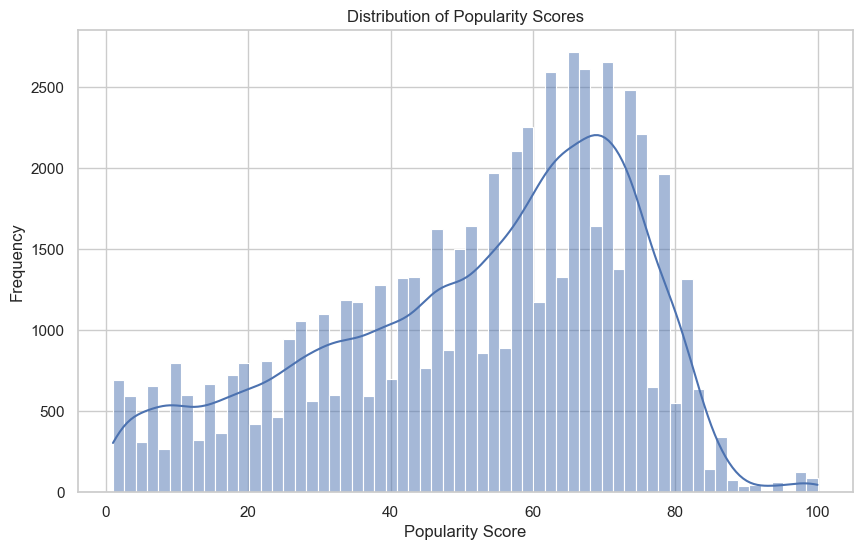

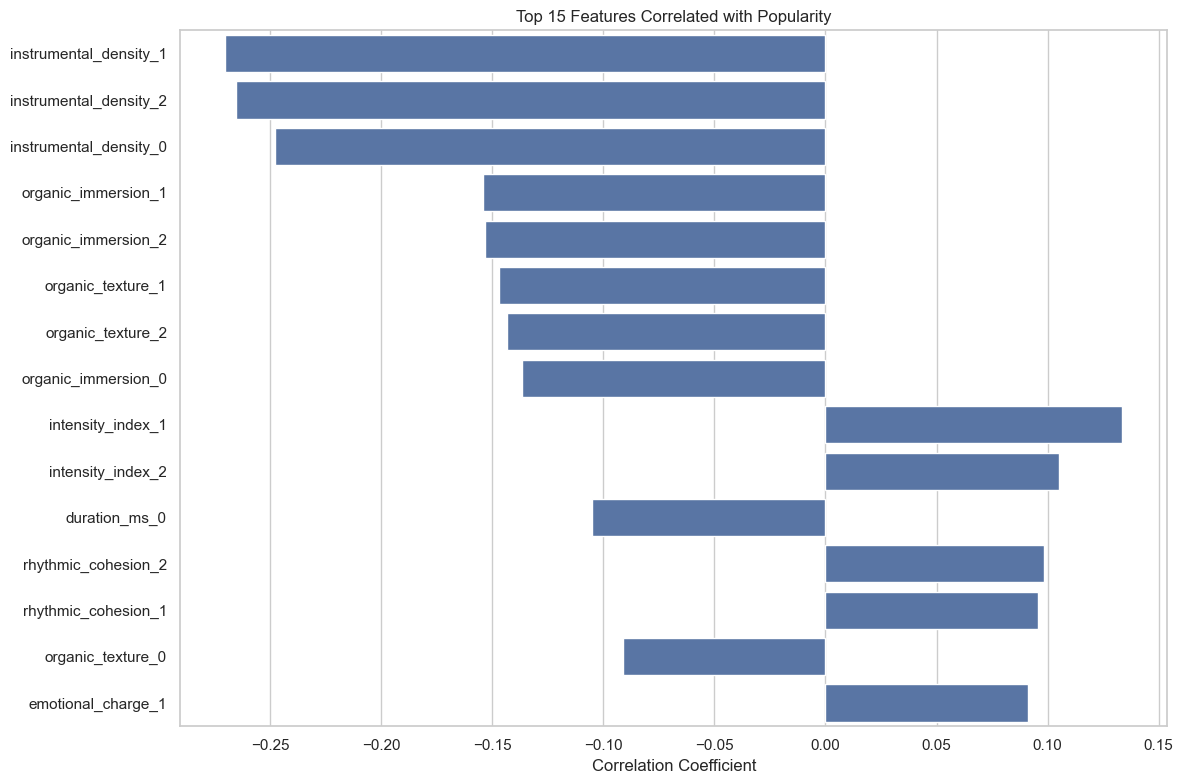


Preprocessing data...

Performing feature engineering...

Handling outliers...

Preparing data for modeling...
Using 69 numeric features and 7 categorical features

Training Random Forest model...

Evaluating model...
Validation RMSE: 15.8829
Validation MAE: 12.4310
Validation R²: 0.4584


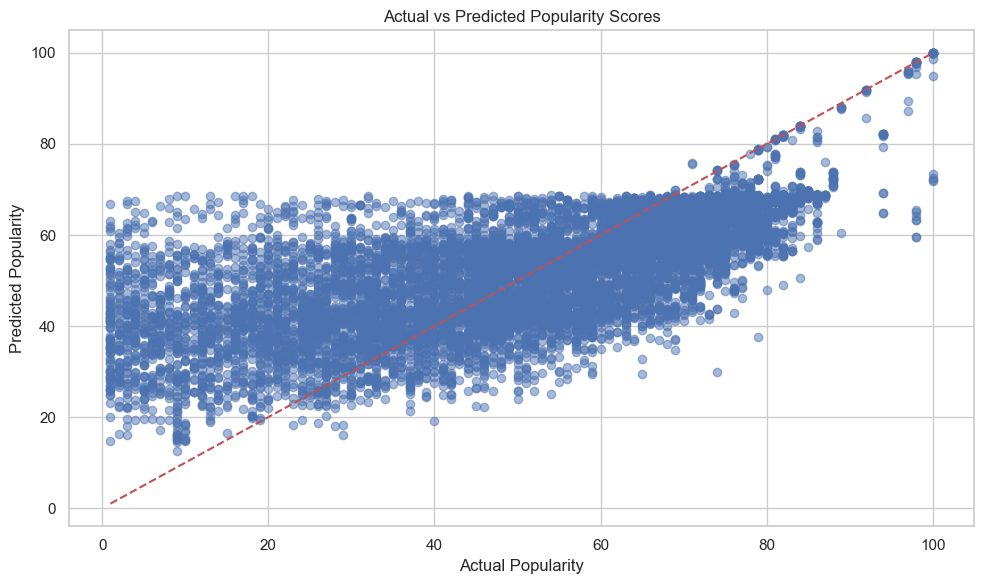

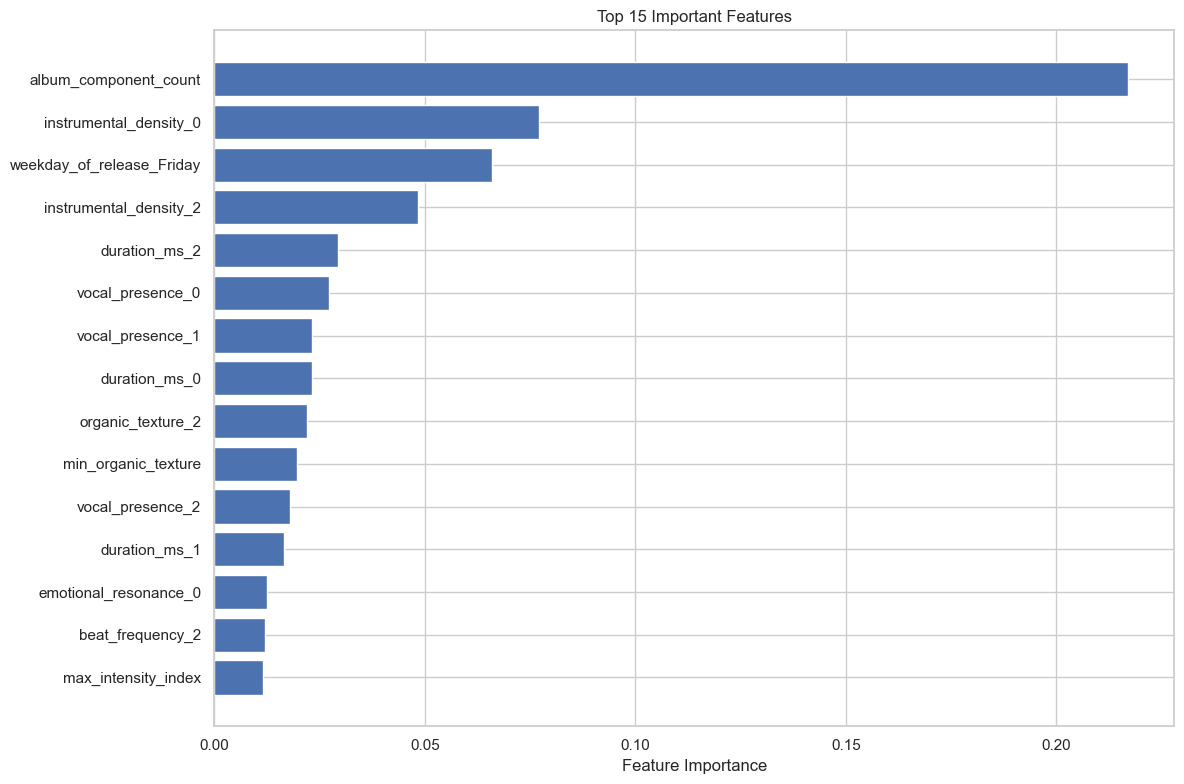


Making predictions on test data...
Submission file created: random_forest_submission.csv

Random Forest model training and prediction completed!


In [1]:
#Random Forest

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import warnings
warnings.filterwarnings('ignore')

# Set the style for visualizations
plt.style.use('ggplot')
sns.set(style="whitegrid")

# Load the data
print("Loading data...")
train_data = pd.read_csv('train.csv')
test_data = pd.read_csv('test.csv')

# Display basic information
print("\nTraining data shape:", train_data.shape)
print("Test data shape:", test_data.shape)

# Check for the target column
print("\nColumns in training data:", train_data.columns.tolist())
if 'target' in train_data.columns:
    print(f"Target column statistics:\n{train_data['target'].describe()}")
else:
    print("Target column not found in training data")

# Explore missing values
print("\nMissing values in training data:")
missing_train = train_data.isnull().sum()
print(missing_train[missing_train > 0])

# Data exploration and visualization
print("\nExploring data distributions...")

# Distribution of target variable
plt.figure(figsize=(10, 6))
sns.histplot(train_data['target'], kde=True)
plt.title('Distribution of Popularity Scores')
plt.xlabel('Popularity Score')
plt.ylabel('Frequency')
plt.show()

# Explore correlations with target
numeric_cols = train_data.select_dtypes(include=['int64', 'float64']).columns.tolist()
if 'target' in numeric_cols:
    numeric_cols.remove('target')

# Calculate correlations with target
correlations = []
for col in numeric_cols:
    if not train_data[col].isnull().all():  # Skip columns with all NaN values
        corr = train_data[col].corr(train_data['target'])
        if not np.isnan(corr):
            correlations.append((col, corr))

# Sort correlations and display top features
correlations.sort(key=lambda x: abs(x[1]), reverse=True)
top_features = correlations[:15]

plt.figure(figsize=(12, 8))
feature_names = [x[0] for x in top_features]
correlation_values = [x[1] for x in top_features]
sns.barplot(x=correlation_values, y=feature_names)
plt.title('Top 15 Features Correlated with Popularity')
plt.xlabel('Correlation Coefficient')
plt.tight_layout()
plt.show()

# Data preprocessing
print("\nPreprocessing data...")

# Combine train and test for preprocessing
train_data['is_train'] = 1
test_data['is_train'] = 0
test_data['target'] = np.nan  # Add placeholder for target in test data
combined_data = pd.concat([train_data, test_data], axis=0, ignore_index=True)

# Handle missing values
for col in combined_data.columns:
    if combined_data[col].dtype in ['int64', 'float64']:
        # Fill numeric columns with median
        combined_data[col] = combined_data[col].fillna(combined_data.loc[combined_data['is_train'] == 1, col].median())
    else:
        # Fill categorical columns with mode
        mode_val = combined_data.loc[combined_data['is_train'] == 1, col].mode()[0] if not combined_data.loc[combined_data['is_train'] == 1, col].mode().empty else "Unknown"
        combined_data[col] = combined_data[col].fillna(mode_val)

# Feature engineering
print("\nPerforming feature engineering...")

# Extract date features from publication_timestamp
if 'publication_timestamp' in combined_data.columns:
    combined_data['publication_timestamp'] = pd.to_datetime(combined_data['publication_timestamp'], errors='coerce')
    combined_data['release_year'] = combined_data['publication_timestamp'].dt.year
    combined_data['release_month'] = combined_data['publication_timestamp'].dt.month
    combined_data['release_day'] = combined_data['publication_timestamp'].dt.day
    combined_data['release_dayofweek'] = combined_data['publication_timestamp'].dt.dayofweek

# Create aggregate features from audio metrics
audio_features = [col for col in combined_data.columns if any(x in col for x in ['rhythmic_cohesion', 'intensity_index', 'organic_texture', 'emotional_charge'])]

for prefix in ['rhythmic_cohesion', 'intensity_index', 'organic_texture', 'emotional_charge']:
    cols = [col for col in combined_data.columns if prefix in col]
    if cols:
        combined_data[f'avg_{prefix}'] = combined_data[cols].mean(axis=1)
        combined_data[f'max_{prefix}'] = combined_data[cols].max(axis=1)
        combined_data[f'min_{prefix}'] = combined_data[cols].min(axis=1)
        combined_data[f'range_{prefix}'] = combined_data[f'max_{prefix}'] - combined_data[f'min_{prefix}']

# Create interaction features
combined_data['energy_dance_product'] = combined_data['avg_intensity_index'] * combined_data['avg_rhythmic_cohesion']
combined_data['acoustic_emotional_ratio'] = combined_data['avg_organic_texture'] / (combined_data['avg_emotional_charge'] + 0.001)  # Adding small value to avoid division by zero

# Handle categorical features
if 'creator_collective' in combined_data.columns:
    combined_data['artist_count'] = combined_data['creator_collective'].str.count(',') + 1

# Outlier detection and handling
print("\nHandling outliers...")

# Function to detect and cap outliers using IQR method
numeric_features = combined_data.select_dtypes(include=['int64', 'float64']).columns.tolist()
numeric_features = [col for col in numeric_features if col not in ['is_train', 'target', 'id']]

for col in numeric_features:
    Q1 = combined_data.loc[combined_data['is_train'] == 1, col].quantile(0.25)
    Q3 = combined_data.loc[combined_data['is_train'] == 1, col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Cap outliers
    combined_data[col] = np.where(combined_data[col] > upper_bound, upper_bound, combined_data[col])
    combined_data[col] = np.where(combined_data[col] < lower_bound, lower_bound, combined_data[col])

# Split back into train and test
train_processed = combined_data[combined_data['is_train'] == 1].drop('is_train', axis=1)
test_processed = combined_data[combined_data['is_train'] == 0].drop(['is_train', 'target'], axis=1)

# Prepare data for modeling
print("\nPreparing data for modeling...")

# Define features to use
categorical_features = train_processed.select_dtypes(include=['object']).columns.tolist()
categorical_features = [col for col in categorical_features if col not in ['id', 'track_identifier']]

numeric_features = train_processed.select_dtypes(include=['int64', 'float64']).columns.tolist()
numeric_features = [col for col in numeric_features if col not in ['target', 'id']]

# Print selected features
print(f"Using {len(numeric_features)} numeric features and {len(categorical_features)} categorical features")

# Prepare X and y
X = train_processed.drop(['target', 'id', 'track_identifier'], axis=1, errors='ignore')
y = train_processed['target']

# Split data for validation
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# Create preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

# Train Random Forest model
print("\nTraining Random Forest model...")
rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

# Create and fit pipeline
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', rf_model)
])

pipeline.fit(X_train, y_train)

# Evaluate model
print("\nEvaluating model...")
y_pred_val = pipeline.predict(X_val)

# Calculate metrics
rmse = np.sqrt(mean_squared_error(y_val, y_pred_val))
mae = mean_absolute_error(y_val, y_pred_val)
r2 = r2_score(y_val, y_pred_val)

print(f"Validation RMSE: {rmse:.4f}")
print(f"Validation MAE: {mae:.4f}")
print(f"Validation R²: {r2:.4f}")

# Visualize actual vs predicted
plt.figure(figsize=(10, 6))
plt.scatter(y_val, y_pred_val, alpha=0.5)
plt.plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 'r--')
plt.xlabel('Actual Popularity')
plt.ylabel('Predicted Popularity')
plt.title('Actual vs Predicted Popularity Scores')
plt.tight_layout()
plt.show()

# Feature importance
feature_names = numeric_features + list(pipeline.named_steps['preprocessor'].transformers_[1][1].get_feature_names_out(categorical_features))
feature_importances = pipeline.named_steps['model'].feature_importances_

# Sort feature importances
indices = np.argsort(feature_importances)[-15:]  # Get indices of top 15 features
plt.figure(figsize=(12, 8))
plt.barh(range(len(indices)), feature_importances[indices], align='center')
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel('Feature Importance')
plt.title('Top 15 Important Features')
plt.tight_layout()
plt.show()

# Make predictions on test data
print("\nMaking predictions on test data...")
test_predictions = pipeline.predict(test_processed.drop(['id', 'track_identifier'], axis=1, errors='ignore'))

# Create submission file
submission = pd.DataFrame({
    'id': test_processed['id'],
    'target': test_predictions
})

# Ensure predictions are within valid range (0-100)
submission['target'] = submission['target'].clip(0, 100)

# Save submission file
submission.to_csv('submission8.csv', index=False)
print("Submission file created: random_forest_submission.csv")

# Print final message
print("\nRandom Forest model training and prediction completed!")